# M4 — Price, demand and delivery scenarios

A capacity reseller can lose money even when its selling price exceeds its buying rate. It may have to pay for more hours than customers use, or pay suppliers before customer cash arrives. We separate changes in demand, price and delivery timing to understand their different effects.

Read [M3](M3_benchmark_basis_risk.ipynb) first. We start with a business that rents computer time and sells it. Later, we clearly switch to a different buyer with a financial hedge.

The reseller buys **7,200 GPU-hours at USD 5** for one block of service planned in month 1. It expects to sell 5,400 hours at USD 8. The supplier's bill is paid at the end of month 1 in every case. There is no owned hardware, supplier refund or automatic payment for failed service.

All cases are **hypothetical**. We change demand, price and timing separately. We do not say which case is most likely.

In [1]:
# Install the teaching package from GitHub when running in Google Colab.
# Local Jupyter uses the repository's existing environment.
import subprocess
import sys

if "google.colab" in sys.modules:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "liquid-compute[colab] @ git+https://github.com/zach189/education.git@main",
        ]
    )
    from google.colab import output

    output.enable_custom_widget_manager()

In [2]:
from IPython.display import display

from liquid_compute.education import (
    explore_finance_series,
    plot_finance_series,
    show_finance_table,
)
from liquid_compute.hedging import basis_exposure_summary, forward_settlements_usd
from liquid_compute.scenarios import OperatingScenario, evaluate_reseller_scenarios

purchased_gpu_hours = 7_200
supplier_rate = 5.0
cases = (
    OperatingScenario("Base", 8, 5_400),
    OperatingScenario("Half demand", 8, 2_700),
    OperatingScenario("Lower price", 6, 5_400),
    OperatingScenario("One-month delay", 8, 5_400, 1),
)
print("Supplier commitment: 7,200 GPU-hours; payment at month 1 in every case.")

Supplier commitment: 7,200 GPU-hours; payment at month 1 in every case.


## Sell fewer hours, but pay the same bill

Start with **5,400 × USD 8** of customer receipts. Subtract **7,200 × USD 5** of supplier cost.

Then halve the hours customers buy. Keep the supplier cost unchanged.

These are unused hours we already agreed to rent. The supplier commitment remains payable even if no customer uses the capacity. A negative contribution is a valid economic outcome and stays visible in the results.

In [3]:
supplier_cash_usd = 7_200 * 5
base_contribution_usd = 5_400 * 8 - supplier_cash_usd
half_demand_contribution_usd = 2_700 * 8 - supplier_cash_usd
show_finance_table(
    ["Direct case", "Revenue (USD)", "Committed rent (USD)", "Contribution (USD)"],
    [
        ["Base", 5_400 * 8, supplier_cash_usd, base_contribution_usd],
        ["Half demand", 2_700 * 8, supplier_cash_usd, half_demand_contribution_usd],
    ],
)

| Direct case | Revenue (USD) | Committed rent (USD) | Contribution (USD) |
| --- | --- | --- | --- |
| Base | 43,200.00 | 36,000.00 | 7,200.00 |
| Half demand | 21,600.00 | 36,000.00 | -14,400.00 |

The starting contribution is **USD 7,200**. Selling half as many hours produces a **USD 14,400 loss**.

We still charge USD 3 more per sold hour than the supplier's rate. But we pay for more hours than we sell.

## Change one thing at a time

For a delay, move the service and the entire customer payment to the later month. Keep the supplier payment in month 1. That is our chosen contract assumption, not a rule all providers use.

Keep the schedule open until the final receipt or payment. Later money must not disappear just because it arrives outside the original month. Any funding gap is reported without assuming a new loan or owner contribution.

In [4]:
results = evaluate_reseller_scenarios(
    cases,
    purchased_gpu_hours=purchased_gpu_hours,
    supplier_usd_per_gpu_hour=supplier_rate,
)


def summary(rows):
    show_finance_table(
        [
            "Case",
            "Billed GPU-hours",
            "Delivery month",
            "Supplier commitment (USD)",
            "Contribution (USD)",
            "Funding need (USD)",
        ],
        [
            [
                r.name,
                r.realized_billed_gpu_hours,
                r.delivered_month,
                r.supplier_commitment_usd,
                r.total_contribution_usd,
                r.funding_requirement_usd,
            ]
            for r in rows
        ],
    )


summary(results)

| Case | Billed GPU-hours | Delivery month | Supplier commitment (USD) | Contribution (USD) | Funding need (USD) |
| --- | --- | --- | --- | --- | --- |
| Base | 5,400.00 | 1.00 | 36,000.00 | 7,200.00 | 0.00 |
| Half demand | 2,700.00 | 1.00 | 36,000.00 | -14,400.00 | 14,400.00 |
| Lower price | 5,400.00 | 1.00 | 36,000.00 | -3,600.00 | 3,600.00 |
| One-month delay | 5,400.00 | 2.00 | 36,000.00 | 7,200.00 | 36,000.00 |

The lower-price case loses **USD 3,600**. The delay case still earns **USD 7,200 total**, but needs **USD 36,000 before the customer pays**.

Lower prices or fewer sales change the total result. In this particular delay case, the same money arrives later, so only the cash timing changes.

Each chart bar is one separate case. The delay bar has the same total as the starting case; its extra cash need appears in the table. A good final total does not pay an earlier bill by itself.

The optional controls combine changes in sold hours and price. They do not allow selling more hours than we bought without adding a separate purchase. Editable inputs work too.

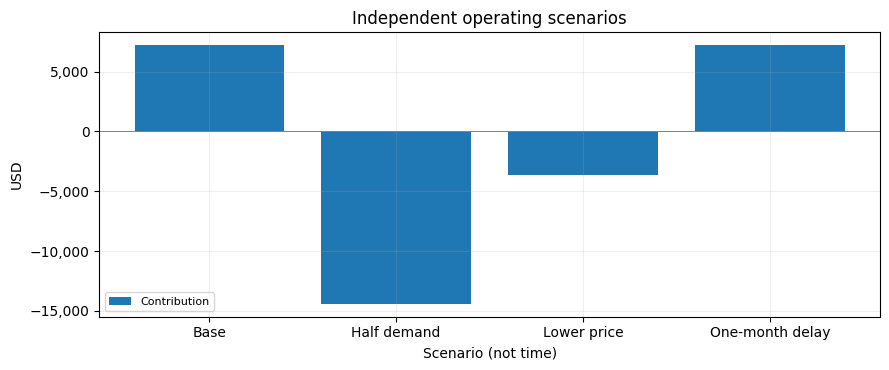

In [5]:
display(
    plot_finance_series(
        {"Contribution": [r.total_contribution_usd for r in results]},
        title="Independent operating scenarios",
        xlabel="Scenario (not time)",
        bar=True,
        x_tick_labels=[r.name for r in results],
    )
)


def operating_explorer(values, capacity=purchased_gpu_hours, rate=supplier_rate):
    from liquid_compute.scenarios import OperatingScenario, evaluate_reseller_scenarios

    rows = evaluate_reseller_scenarios(
        [
            OperatingScenario("Base", 8, 5_400),
            OperatingScenario(
                "Changed", values["Customer USD/GPU-hour"], values["Billed GPU-hours"]
            ),
        ],
        purchased_gpu_hours=capacity,
        supplier_usd_per_gpu_hour=rate,
    )
    return {"Contribution": [r.total_contribution_usd for r in rows]}


explore_finance_series(
    {"Customer USD/GPU-hour": 8.0, "Billed GPU-hours": 5_400.0},
    operating_explorer,
    title="Price and billed demand",
    xlabel="Scenario",
    bar=True,
    x_tick_labels=["Base", "Changed"],
);

Changing two things at once can make a loss harder to explain. The fixed examples change one thing at a time; the controls let you combine changes on purpose. Each bar represents a separate scenario, rather than an average across possible outcomes.

## Experiment 1 — Customers cancel

Reduce billed hours from 5,400 to 2,700, then to zero. The supplier still gets **USD 36,000**. We assume no cancellation fee paid by customers and no refund from the supplier.

F3 explains detailed cancellation and acceptance rules. Here we simply supply the number of hours customers actually buy.

In [6]:
cancellation_cases = evaluate_reseller_scenarios(
    [
        OperatingScenario("Original demand", 8, 5_400),
        OperatingScenario("Half canceled", 8, 2_700),
        OperatingScenario("All canceled", 8, 0),
    ],
    purchased_gpu_hours=7_200,
    supplier_usd_per_gpu_hour=5,
)
summary(cancellation_cases)

| Case | Billed GPU-hours | Delivery month | Supplier commitment (USD) | Contribution (USD) | Funding need (USD) |
| --- | --- | --- | --- | --- | --- |
| Original demand | 5,400.00 | 1.00 | 36,000.00 | 7,200.00 | 0.00 |
| Half canceled | 2,700.00 | 1.00 | 36,000.00 | -14,400.00 | 14,400.00 |
| All canceled | 0.00 | 1.00 | 36,000.00 | -36,000.00 | 36,000.00 |

With no customers, we lose **USD 36,000** and need that much cash to pay the supplier. Zero demand does not cancel our purchase or create an asset we can sell.

## Experiment 2 — A different buyer needs fewer hours

Now switch businesses. A buyer has a financial hedge covering 7,200 hours at a USD 5 strike. It buys compute at the current price and now needs only 3,600 hours. Both the actual price and benchmark are USD 3.

Compute costs **USD 10,800**. The hedge requires a **USD 14,400 payment**, making combined cost **USD 25,200**.

This buyer has no fixed agreement to buy 7,200 physical hours. The obligation that survives is the financial hedge. We reuse M2 and M3's calculations.

In [7]:
buyer_settlements = forward_settlements_usd(
    benchmark_usd_per_gpu_hour=[3],
    strike_usd_per_gpu_hour=5,
    hedge_gpu_hours=[7_200],
    settlement_months=[1],
    side="buyer",
)
buyer_results = []
for physical_hours in (3_600, 0):
    result = basis_exposure_summary(
        actual_usd_per_gpu_hour=[3],
        physical_gpu_hours=[physical_hours],
        benchmark_usd_per_gpu_hour=[3],
        hedge_gpu_hours=[7_200],
        strike_usd_per_gpu_hour=5,
        physical_payment_months=[1],
        settlements=buyer_settlements,
    )
    buyer_results.append(
        [
            physical_hours,
            result.unhedged_cost_usd,
            result.hedge_receipts_usd,
            result.net_cost_usd,
        ]
    )
show_finance_table(
    [
        "Actual need (GPU-hours)",
        "Physical cost (USD)",
        "Signed hedge receipt (USD)",
        "Combined cost (USD)",
    ],
    buyer_results,
)

| Actual need (GPU-hours) | Physical cost (USD) | Signed hedge receipt (USD) | Combined cost (USD) |
| --- | --- | --- | --- |
| 3,600.00 | 10,800.00 | -14,400.00 | 25,200.00 |
| 0.00 | 0.00 | -14,400.00 | 14,400.00 |

Even at **zero physical need**, the buyer still pays **USD 14,400 on the hedge**. A negative hedge receipt means money going out.

Canceling the hedge too would be a different case. Ending it might cost money; we have not assumed free cancellation.

## Experiment 3 — Service and customer cash arrive late

Return to the reseller. Pay the supplier in month 1, deliver the same service and collect the customer payment in month 2.

Keep the full service amount and price. Add no penalty, refund or extra purchase. Show both months so the wait for cash stays visible.

In [8]:
delayed = results[3]
show_finance_table(
    [
        "Month",
        "Customer cash (USD)",
        "Supplier cash (USD)",
        "Net cash (USD)",
        "Cumulative cash (USD)",
    ],
    [
        [
            t,
            delayed.customer_receipts_usd[t],
            delayed.supplier_payments_usd[t],
            delayed.net_cash_usd[t],
            delayed.cumulative_cash_usd[t],
        ]
        for t in range(len(delayed.net_cash_usd))
    ],
)

| Month | Customer cash (USD) | Supplier cash (USD) | Net cash (USD) | Cumulative cash (USD) |
| --- | --- | --- | --- | --- |
| 0.00 | 0.00 | 0.00 | 0.00 | 0.00 |
| 1.00 | 0.00 | 36,000.00 | -36,000.00 | -36,000.00 |
| 2.00 | 43,200.00 | 0.00 | 43,200.00 | 7,200.00 |

Cash falls to **−USD 36,000 in month 1**, then rises to **+USD 7,200 after month 2**. The total result is unchanged, but the needed starting cash rises from zero to **USD 36,000**.

This repeats Notebook 2's lesson: how much money we make and when we need money are separate questions.

Supplier commitments, sold hours, selling prices and covered hedge hours are separate inputs. One price hedge cannot guarantee their combined outcome. Compare the total result and the cash needed along the way. We have not assigned chances to these cases.

In [9]:
summary(results)
print("Scenarios are unweighted; no probability or expected-value claim is made.")

| Case | Billed GPU-hours | Delivery month | Supplier commitment (USD) | Contribution (USD) | Funding need (USD) |
| --- | --- | --- | --- | --- | --- |
| Base | 5,400.00 | 1.00 | 36,000.00 | 7,200.00 | 0.00 |
| Half demand | 2,700.00 | 1.00 | 36,000.00 | -14,400.00 | 14,400.00 |
| Lower price | 5,400.00 | 1.00 | 36,000.00 | -3,600.00 | 3,600.00 |
| One-month delay | 5,400.00 | 2.00 | 36,000.00 | 7,200.00 | 36,000.00 |

Scenarios are unweighted; no probability or expected-value claim is made.


## Next — Option payoffs and premiums

Continue to **M5: Calls and puts**. Unlike a forward, an option can provide a nonnegative payoff to its buyer, in exchange for a price paid for the option.

M2's [CME cash-flow reference](https://www.cmegroup.com/education/courses/introduction-to-base-metals/cash-flow-in-metals-futures-vs-forwards) and M3's [basis explanation](https://www.cmegroup.com/education/courses/introduction-to-grains-and-oilseeds/learn-about-basis-grains) support those earlier concepts. Our demand, cancellation and delivery cases are hypothetical, not claims about actual contracts or measured market behavior.